In [2]:
## Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib


In [3]:
## Step 2: Load Data
df = pd.read_csv("24f8996b599028111827.csv") 

In [4]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
#Step 3: Explore the data
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    

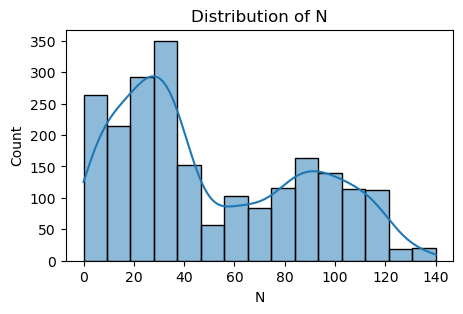

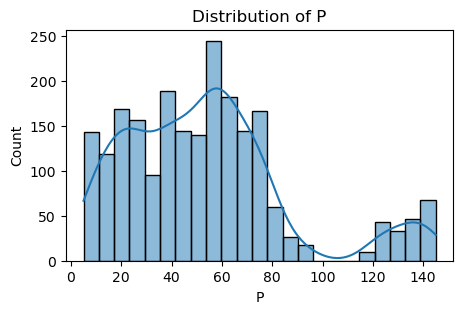

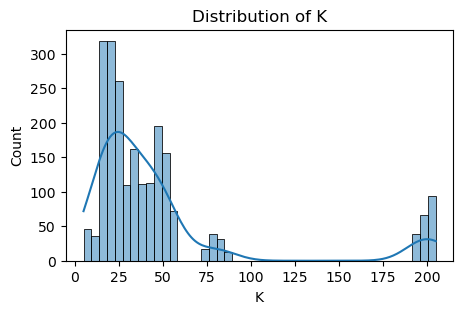

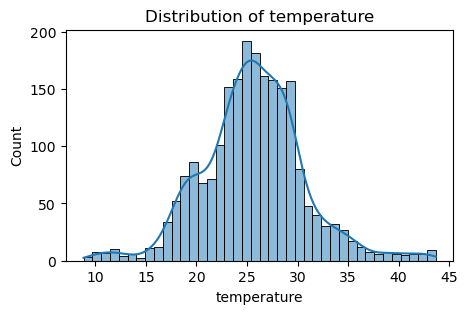

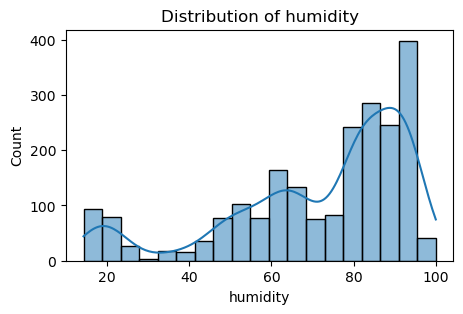

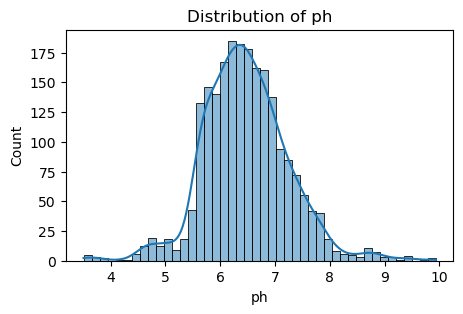

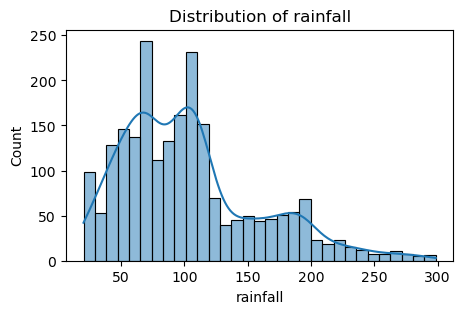

In [6]:
## Step 4: Visualize Distributions
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
for col in features:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [7]:
## Step 5: Preprocessing
X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [8]:
## Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [9]:

## Step 7: Model Training
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

RandomForestClassifier()

In [10]:
## Step 8: Evaluation
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9931818181818182
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00     

In [11]:
## Step 9: Save Model
joblib.dump(clf, "crop_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")


['label_encoder.pkl']

In [12]:
df1 = pd.read_csv("b835ac31a79726111827.csv")  # Crop Recommendation dataset


C:\Users\trish\AppData\Local\Temp\ipykernel_19804\3070529361.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df1.corr(), annot=True)


<Axes: >

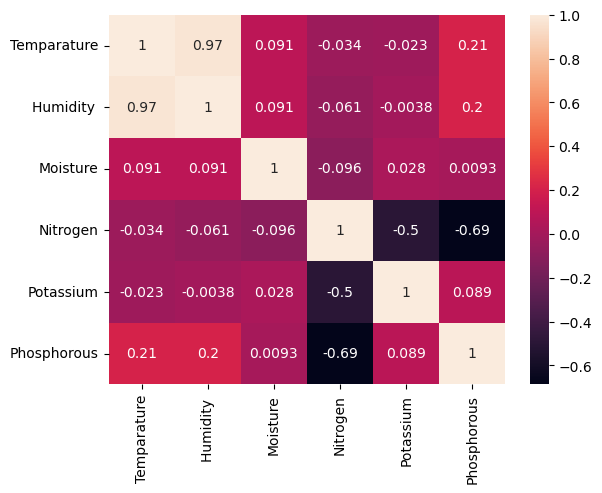

In [13]:
sns.heatmap(df1.corr(), annot=True)


In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Step 1: Strip column names (safety)
df1.columns = df1.columns.str.strip()

# Step 2: Encode categorical columns (excluding the target)
categorical_cols = df1.drop('Crop Type', axis=1).select_dtypes(include='object').columns
df1[categorical_cols] = df1[categorical_cols].apply(LabelEncoder().fit_transform)

# Step 3: Separate features and target
X = df1.drop('Crop Type', axis=1)
y = df1['Crop Type']

# Step 4: Encode the target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Step 5: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [22]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load your dataset
df1 = pd.read_csv('b835ac31a79726111827.csv') 

# Step 1: Clean column names
df1.columns = df1.columns.str.strip()

# Step 2: Encode categorical columns (except target)
categorical_cols = df1.drop('Crop Type', axis=1).select_dtypes(include='object').columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])
    label_encoders[col] = le  # store encoders if needed for inverse transform later

# Step 3: Encode target variable
target_encoder = LabelEncoder()
df1['Crop Type'] = target_encoder.fit_transform(df1['Crop Type'])

# Step 4: Split into features and target
X = df1.drop('Crop Type', axis=1)
y = df1['Crop Type']

# Step 5: Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✅ Now X_scaled and y are ready to use for model training


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 7: Train Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 8: Make predictions
y_pred = model.predict(X_test)

# Step 9: Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Optional: detailed performance
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))


Accuracy: 0.50

Classification Report:

              precision    recall  f1-score   support

      Barley       0.00      0.00      0.00         2
      Cotton       1.00      1.00      1.00         4
 Ground Nuts       0.00      0.00      0.00         0
       Maize       0.00      0.00      0.00         2
     Millets       0.14      1.00      0.25         1
   Oil seeds       0.00      0.00      0.00         2
       Paddy       1.00      1.00      1.00         2
      Pulses       1.00      0.50      0.67         2
   Sugarcane       0.00      0.00      0.00         1
     Tobacco       1.00      0.67      0.80         3
       Wheat       0.00      0.00      0.00         1

    accuracy                           0.50        20
   macro avg       0.38      0.38      0.34        20
weighted avg       0.56      0.50      0.50        20



C:\Users\trish\ANACONDA\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\trish\ANACONDA\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\trish\ANACONDA\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\trish\ANACONDA\lib\site-packages\sklearn\m

In [24]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, verbose=2, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Get the best parameters
print("Best parameters found: ", grid_search.best_params_)

# Use the best model
model = grid_search.best_estimator_


Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters found:  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [26]:
import joblib

# Save the model
joblib.dump(model, 'crop.pkl')


['crop.pkl']

In [27]:
import pandas as pd

# Load your dataset 
data = pd.read_csv('b835ac31a79726111827.csv')

# Show the first few rows of the dataset
print(data.head())

# Show the column names (features)
print(data.columns)


   Temparature  Humidity   Moisture Soil Type  Crop Type  Nitrogen  Potassium  \
0           26         52        38     Sandy      Maize        37          0   
1           29         52        45     Loamy  Sugarcane        12          0   
2           34         65        62     Black     Cotton         7          9   
3           32         62        34       Red    Tobacco        22          0   
4           28         54        46    Clayey      Paddy        35          0   

   Phosphorous Fertilizer Name  
0            0            Urea  
1           36             DAP  
2           30        14-35-14  
3           20           28-28  
4            0            Urea  
Index(['Temparature', 'Humidity ', 'Moisture', 'Soil Type', 'Crop Type',
       'Nitrogen', 'Potassium', 'Phosphorous', 'Fertilizer Name'],
      dtype='object')


In [28]:
import joblib
from sklearn.preprocessing import LabelEncoder

# Sample data for fitting encoders (you should replace this with the actual data used for training the model)
soil_types = ['Sandy', 'Loamy', 'Black', 'Red', 'Clayey']
crop_types = ['Maize', 'Sugarcane', 'Cotton', 'Tobacco', 'Paddy']
fertilizers = ['Fertilizer A', 'Fertilizer B', 'Fertilizer C', 'Fertilizer D']

# Initialize LabelEncoders
le_soil = LabelEncoder()
le_crop = LabelEncoder()
le_fertilizer = LabelEncoder()

# Fit the encoders with the sample data
le_soil.fit(soil_types)
le_crop.fit(crop_types)
le_fertilizer.fit(fertilizers)

# Save the encoders using joblib
joblib.dump(le_soil, 'le_soil.pkl')
joblib.dump(le_crop, 'le_crop.pkl')
joblib.dump(le_fertilizer, 'le_fertilizer.pkl')

print("LabelEncoders for Soil, Crop, and Fertilizer saved successfully!")


LabelEncoders for Soil, Crop, and Fertilizer saved successfully!
